In [39]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

In [40]:
load_dotenv()

True

In [41]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [42]:
class summarystate(MessagesState):
    summary: str

In [43]:
def chat_node(state: summarystate):
    messages = []
    
    # we will check for the messages in state
    if state['summary']:
        messages.append({
            "role" : "system",
            "content" : f"Conversation Summary {state['messages']}"
        })
        
    # then we will attach this in the state
    messages.extend(state["messages"])
    
    print(messages)
    
    response = LLM.invoke(messages)
    return {"messages" : [response]}

In [44]:
# now building our summarizer node
def summarry_node(state: summarystate):
    
    # getting the summary from the state
    existing_summary = state['summary']
    
    #building the prompt 
    if existing_summary:
        prompt = (f"existing summary\n {state['summary']}"
        "extend the summary using the new conversation above")
    else:
        prompt = "Summarize the above conversation"
        
    # combining both 
    message_for_summary = state['message'] + [HumanMessage(content=prompt)] 
    
    # giving this message to llm(summary generation)
    response = LLM.invoke(message_for_summary)
    
    # performing deletion for the rest and keeping just 2
    message_for_deletion = state['messages'][:-2]
    
    # now returining 2 things 
    return {
        "Summary" : response.content,
        "Messages" : [RemoveMessage(id=m.id) for m in message_for_deletion]
    }

In [45]:
def should_summarize(state: summarystate):
    return len(state['messages'])>6

In [46]:
#building the node
graph = StateGraph(summarystate)

graph.add_node("chat_node", chat_node)
graph.add_node("summarry_node", summarry_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_summarize,{True: "summarry_node", False: "__end__"})
graph.add_edge("summarry_node", END)


In [47]:
#implementing checkpointer
memory = InMemorySaver()
STM_summarize = graph.compile(checkpointer=memory)


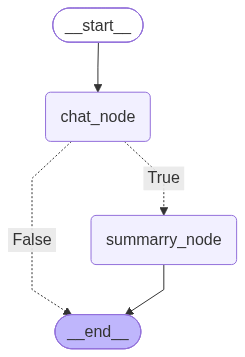

In [48]:
from IPython.display import Image
Image(STM_summarize.get_graph().draw_mermaid_png())

In [49]:
config = {"configurable": {"thread_id": "t1"}}

In [50]:
# gives the current version of the state
def show_state():
    snap = STM_summarize.get_state(config)
    vals = snap.values

    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")

    for m in vals.get("messages", []):
        print(" -", type(m).__name__, ":", m.content[:80])

In [51]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="quantum Physics")], 'summary' : ""}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='4382bd13-6975-41a0-807a-c1a5b14d8390')]
{'messages': [HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='4382bd13-6975-41a0-807a-c1a5b14d8390'), AIMessage(content='Sure! Here’s a quick‑but‑comprehensive tour of the main ideas, history, and modern applications of **quantum physics** (also called quantum mechanics). Feel free to let me know if you’d like to dive deeper into any particular topic.\n\n---\n\n## 1. Why “Quantum”?\n\nClassical physics (Newton, Maxwell, etc.) treats objects as having definite positions, velocities, and trajectories. Experiments at the atomic‑scale in the early 20th\u202fcentury showed that this picture breaks down. The word **quantum** comes from the Latin *quantus* (“how much”) and refers to the fact that many physical quantities (energy, angular momentum, electric charge, etc.) are **discrete**—they come in indivisible “chunks”.\n\n--

In [52]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="how albert einstine related to this")]}, config = config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='4382bd13-6975-41a0-807a-c1a5b14d8390'), AIMessage(content='Sure! Here’s a quick‑but‑comprehensive tour of the main ideas, history, and modern applications of **quantum physics** (also called quantum mechanics). Feel free to let me know if you’d like to dive deeper into any particular topic.\n\n---\n\n## 1. Why “Quantum”?\n\nClassical physics (Newton, Maxwell, etc.) treats objects as having definite positions, velocities, and trajectories. Experiments at the atomic‑scale in the early 20th\u202fcentury showed that this picture breaks down. The word **quantum** comes from the Latin *quantus* (“how much”) and refers to the fact that many physical quantities (energy, angular momentum, electric charge, etc.) are **discrete**—they come in indivisible “chunks”.\n\n---\n\n## 2. Core Principles\n\n| Principle | What It Says | Famous Thought Experiment / Test |\n|-----------|--------------|-------------------

In [57]:
out = STM_summarize.invoke({"messages": [HumanMessage(content=" give some works of einstine")]}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='4382bd13-6975-41a0-807a-c1a5b14d8390'), AIMessage(content='Sure! Here’s a quick‑but‑comprehensive tour of the main ideas, history, and modern applications of **quantum physics** (also called quantum mechanics). Feel free to let me know if you’d like to dive deeper into any particular topic.\n\n---\n\n## 1. Why “Quantum”?\n\nClassical physics (Newton, Maxwell, etc.) treats objects as having definite positions, velocities, and trajectories. Experiments at the atomic‑scale in the early 20th\u202fcentury showed that this picture breaks down. The word **quantum** comes from the Latin *quantus* (“how much”) and refers to the fact that many physical quantities (energy, angular momentum, electric charge, etc.) are **discrete**—they come in indivisible “chunks”.\n\n---\n\n## 2. Core Principles\n\n| Principle | What It Says | Famous Thought Experiment / Test |\n|-----------|--------------|-------------------

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jrmmana9f02amgrrctc566cg` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8328, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}